In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
from sklearn.model_selection import train_test_split


from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV

from sklearn import metrics
from sklearn.feature_selection import SelectFromModel

import lightgbm as lgbm


In [3]:
def removeOutliers(df):
    percentile90 = df['soldPrice'].quantile(0.90)
    percentile10 = df['soldPrice'].quantile(0.10)

    iqr = percentile90 - percentile10

    upper_limit = percentile90 + 3 * iqr
    lower_limit = percentile10 - 3 * iqr

    df = df[df['soldPrice'] < upper_limit]
    df = df[df['soldPrice'] > lower_limit]

    return df

In [4]:
data = pd.read_csv(os.getcwd()+"\\data\\data.csv")

In [5]:
data.shape

(322448, 1337)

Split onto train/test 

In [6]:
x, y = data.drop(['soldPrice'], axis = 1), data['soldPrice']

In [7]:
import re
x = x.rename(columns = lambda z: re.sub('[^A-Za-z0-9_]+', '', z))

In [8]:
x.columns

Index(['originalPrice', 'listPrice', 'latitude', 'longitude', 'DOM',
       'avg_sqft', 'ppsqft', 'bathtobed_ratio', 'listPrice_by_area',
       'listPrice_by_city',
       ...
       'style_BungalowRaised', 'style_IndustrialLoft', 'style_Loft',
       'style_MultiLevel', 'style_Other', 'style_Sidesplit3',
       'style_Sidesplit4', 'style_Sidesplit5', 'style_StackedTownhse',
       'style_WarehouseLoft'],
      dtype='object', length=1336)

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state=42)

print('Shape of x_train: ' + str(x_train.shape))
print('Shape of y_train: ' + str(y_train.shape))
print('Shape of x_test: ' + str(x_test.shape))
print('Shape of y_test: ' + str(y_test.shape))

Shape of x_train: (225713, 1336)
Shape of y_train: (225713,)
Shape of x_test: (96735, 1336)
Shape of y_test: (96735,)


In [10]:
x_train.columns

Index(['originalPrice', 'listPrice', 'latitude', 'longitude', 'DOM',
       'avg_sqft', 'ppsqft', 'bathtobed_ratio', 'listPrice_by_area',
       'listPrice_by_city',
       ...
       'style_BungalowRaised', 'style_IndustrialLoft', 'style_Loft',
       'style_MultiLevel', 'style_Other', 'style_Sidesplit3',
       'style_Sidesplit4', 'style_Sidesplit5', 'style_StackedTownhse',
       'style_WarehouseLoft'],
      dtype='object', length=1336)

In [11]:
#Define XGBoost parameters tree_method = 'gpu_hist'
base_regressor = lgbm.LGBMRegressor(learning_rate = 0.3,random_state=0)

#Get top 100 features using XGBoost
select_feat = SelectFromModel(base_regressor,threshold=-np.inf,max_features=25).fit(x_train,y_train)

In [12]:
#Get indices of top 100 features 
feat_index = select_feat.get_support()

#Rename the columns of training and test sets to include column names of top 100 features
train_x = pd.DataFrame(x_train, columns = x_train.columns[feat_index])
test_x = pd.DataFrame(x_test, columns= x_test.columns[feat_index])


#Print the top 100 features
for col in x_train.columns[feat_index]:
    print(col)

originalPrice
listPrice
latitude
longitude
DOM
avg_sqft
ppsqft
bathtobed_ratio
listPrice_by_area
listPrice_by_city
city_EastLutherGrandValley
city_Markham
district_TorontoC01
neighborhood_GrandValley
neighborhood_OldMarkhamVillage
neighborhood_RuralInnisfil
numBathrooms_1
numBathrooms_2
numBathrooms_3
numBathrooms_4
numBedrooms_1
numBedrooms_3
numBedrooms_4
style_2Storey
style_Bungalow


<AxesSubplot:title={'center':'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

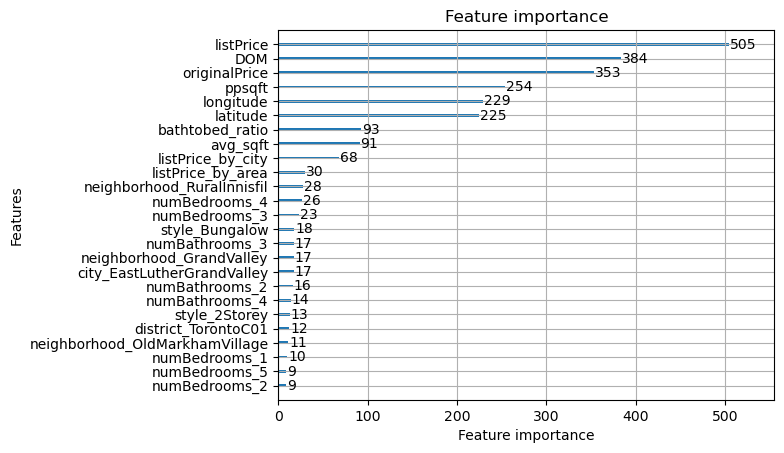

In [13]:
lgbm.plot_importance(base_regressor.fit(x_train,y_train), max_num_features = 25)

In [14]:
#LightGBM parameters
params = {
        'colsample_bytree': [0.5, 0.75, 1],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.25, 0.5, 1.0],
        'max_depth': [5, 7, 9, 11],
        'num_leaves': [15,30,45],
        'reg_lambda': [0.01, 0.5, 0.1],
        'min_child_samples': [10,20,30],
        }

In [15]:
#Define XGBoost base model 
# lgbm_model = lgbm.LGBMRegressor(n_estimators=100, device = 'gpu')

# grid_search = GridSearchCV(lgbm_model, params, cv=5,verbose=3)
# grid_search.fit(train_x, y_train)

Saving the grid search results

In [16]:
# #Get results of gridsearch 
# grid_results_df = pd.DataFrame(grid_search.cv_results_)
# #Save to csv
# grid_results_df.to_csv("GridSearch_CV_results.csv", index = False)

Loading the grid search results

In [17]:
grid_results_df = pd.read_csv(os.getcwd()+"\\GridSearch_CV_results.csv")
#grid_results_df.sort_values(by=['rank_test_score']).head()

In [18]:
import ast
params = ast.literal_eval(str(grid_results_df.sort_values(by=['rank_test_score'])['params'].values[0]))

In [19]:
best_model = lgbm.LGBMRegressor(n_estimators=100, device = 'gpu')
best_model.set_params(**params)

best_model = best_model.fit(train_x, y_train)
best_model

LGBMRegressor(colsample_bytree=1, device='gpu', max_depth=5,
              min_child_samples=10, num_leaves=15, reg_lambda=0.5,
              subsample=0.5)

In [20]:
y_pred = best_model.predict(test_x)

In [21]:
metrics.mean_absolute_error(y_test, y_pred)

52.53210621731104

In [22]:
metrics.r2_score(y_test, y_pred)

0.9815126615438714

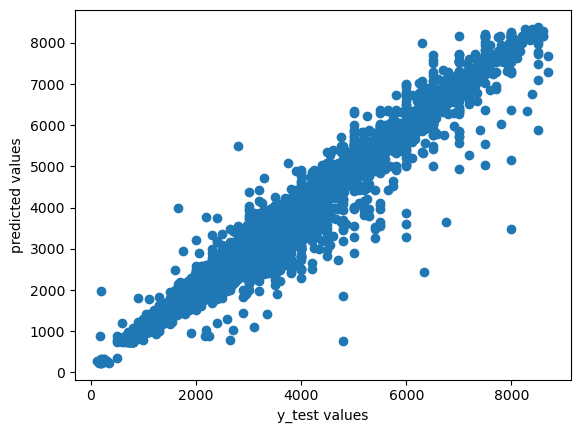

In [23]:
import matplotlib.pyplot as plt

plt.scatter(x = y_test.values,y =  y_pred)
plt.xlabel("y_test values")
plt.ylabel("predicted values")
plt.show()

